# Learning rules × geometry of efficient codes (v3)

**What changed since v2:** running v2 hit a crash — `MDS ... Input X contains NaN` — while
plotting Experiment 2. Root cause: the **`BCM` rule diverged to `NaN` specifically for
the high-capacity classifier (E2M1) model** (`[Exp2] BCM cap=high ... E2M1_loss=nan`;
Experiment 1, with no classifier, ran all 28/28 models to completion without issue). This
is a known BCM failure mode: its postsynaptic activity is unclamped (the real
`BCM_4` class comments *out* the post-activity clamp, so this matches source) and its
threshold `theta` only tracks activity via a slow EMA (`theta_tau=10`), so `mu` and
`theta` can enter a runaway positive-feedback loop; the classifier's extra gradient at
high capacity was enough to tip it over. Section 2/4 below now add:
1. A weight-magnitude clamp inside `PlasticLinear` after every update (a generic
   numerical safety net — the real repo instead relies on a configurable, per-projection
   `weight_bounds`/`weight_constraint` mechanism that this notebook doesn't fully
   replicate, so this is a disclosed, pragmatic substitute, not a source-verified fix).
2. Gradient-norm clipping on the backprop-trained parameters.
3. An early-stop-with-warning if a training run's loss goes non-finite (instead of
   silently continuing and corrupting the weights further).
4. A NaN-safe `embed_probe` that warns and zeroes out any non-finite entries rather than
   crashing downstream MDS/plotting — so one unstable run can no longer take down the
   whole notebook; you'll see an explicit `[warning]` if it happens again.

---

# Learning rules × geometry of efficient codes (v2)

This is a revised version of the notebook, checked line-by-line against the actual
source of both repos (`Milstein-Lab/EIANN`, `EIANN/rules/{hebbian,backprop_like,btsp}.py`,
and `damat-le/geom_eff_codes`, `src/models/beta_vae*.py`, `notebooks/corridors_dataset_generator.ipynb`,
`configs/*.yaml`). Compared to the first version, this one fixes:

1. **Corridors dataset** — the real generator normalizes the Gaussian bump so its peak
   probability is exactly 1.0 (`ps = ps/ps.max()`), not the raw pdf value (≈0.33 for
   σ=1.2). Also matches their final polarity (`1 - raw`), so pixel values are 0 near a
   corridor and 1 in the background (their sample images are plotted with the *inverted*
   `cmap='binary'`, which is why they still look like "white corridors on black" when
   displayed that way).
2. **β-VAE loss** — real code uses **MSE** reconstruction loss (not BCE), the exact
   capacity-annealing schedule from Burgess et al. (`C = clamp(Cmax/C_stop_iter·iter, 0,
   Cmax)`, plus a `/4` damping for the first 60% of the ramp), a separate fixed
   `kld_weight` (≈0.0003) multiplying the whole KLD term in addition to `gamma`
   (300 for reconstruction-only models, 10000 for the classifier hybrids — from
   `configs/bbvae.yaml` / `bbvae_CLF.yaml`), and a classifier loss whose weight ramps in
   *after* capacity has finished annealing (`clf_w = clamp((iter − C_stop_iter)/C_stop_iter,
   0, 1)`), reading from the **sampled** `z`, not `mu`.
3. **Plastic rules** — EIANN trains **one image at a time** (batch_size=1); every rule in
   `EIANN/rules/*.py` operates on single population vectors, not batch-averages. The
   plastic layer below now applies its update **sequentially, sample-by-sample**, within
   each minibatch (the surrounding encoder/decoder/logvar-head still train with ordinary
   batched Adam, for tractable Colab runtime — see the note in Section 3). Also fixed:
   presynaptic (and, for some rules, postsynaptic) activity clamping to `[0,1]`
   (`Ojas_rule`, `BCM_4`, `BP_like_2E`, `Hebbian_Temporal_Contrast`, `BTSP_19` all clamp
   in the real code); `Hebb_WeightNorm` itself has **no built-in normalization** in the
   real repo (it's plain Hebbian) — row-normalization is a *separate* `normalize_weight`
   weight-constraint (divide by current abs-row-sum, multiply by a fixed target `scale`),
   which is now applied as its own step, matching Eq. 9–10 of the paper and
   `EIANN/rules/weight_functions.py::normalize_weight`; `BTSP_19` now implements the real
   three-term (current/past eligibility × current/past instructive-signal) update with
   the actual smooth depression gate (`get_scaled_rectified_sigmoid`), not a simplified
   EMA-trace stand-in.

**What's still a deliberate simplification** (disclosed, not silently swept under the
rug): the encoder/decoder backbone is still a small dense MLP rather than the real conv
stack (robust to build correctly without conv-shape bugs — doesn't change the qualitative
science); and `BP_like_2E`/`Hebbian_Temporal_Contrast`/`BTSP_19`'s "error" signal (`delta`)
is still `-d(loss)/d(mu)` from ordinary autograd rather than a literal two-phase
recurrent-dendrite equilibration (this notebook's architecture is feedforward, not
recurrent E/I circuitry) — but per Eq. 27 of Galloni et al., this is exactly the
*leading-order term* that a true two-phase contrastive/dendritic-target-propagation
update reduces to, so it's a principled approximation, not an arbitrary one.

In [ ]:
!pip install -q scikit-learn scipy matplotlib pandas > /dev/null
import math, time
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from sklearn.manifold import MDS
from scipy.spatial.distance import pdist, squareform
import matplotlib.pyplot as plt
import pandas as pd

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
SEED = 0
np.random.seed(SEED)
torch.manual_seed(SEED)
print("Using device:", device)

Using device: cuda


## 1. The *Corridors* dataset (fixed: normalized bump + real polarity)

Matches `notebooks/corridors_dataset_generator.ipynb` in `geom_eff_codes`: for each
section (upper/lower), the Gaussian bump probability is rescaled to peak at 1.0 at the
corridor's center column, each of the 6 rows in that section independently draws
`Bernoulli(p(col))`, the middle row is forced to 1, and then **the whole image is
inverted** (`1 - raw`). Net effect: pixel value ≈0 at/near a corridor center (and on the
dividing line), ≈1 in the background, with a band of genuine stochastic variability where
the Gaussian bump is neither ~0 nor ~1.

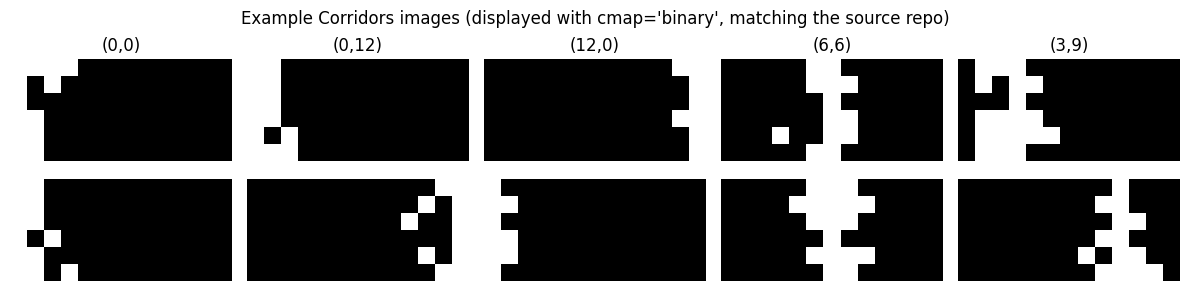

In [ ]:
IMG_SIZE = 13
SIGMA = 1.2

def gaussian_bump_normalized(cols, mu, sigma):
    p = np.exp(-0.5 * ((cols - mu) / sigma) ** 2)
    return p / p.max()  # peak = 1.0 at the corridor center, matching the real generator

def make_corridor_section(mu_pos, n_rows, sigma, rng):
    cols = np.arange(IMG_SIZE)
    probs = gaussian_bump_normalized(cols, mu_pos, sigma)
    section = (rng.random((n_rows, IMG_SIZE)) < probs[None, :]).astype(np.float32)
    return section

def make_corridor_image(x_uc, x_lc, sigma, rng):
    raw = np.zeros((IMG_SIZE, IMG_SIZE), dtype=np.float32)
    raw[0:6, :] = make_corridor_section(x_uc, 6, sigma, rng)
    raw[6, :] = 1.0  # dividing line (pre-inversion)
    raw[7:13, :] = make_corridor_section(x_lc, 6, sigma, rng)
    return 1.0 - raw  # match the real dataset's polarity

class CorridorsDataset(Dataset):
    '''bias: None (balanced) | 'lower_left' (E1M1: x_LC<=6 10x more frequent)
                              | 'aligned'   (E1M2: x_UC==x_LC 10x more frequent)
       task: None, or a callable (x_uc, x_lc) -> int giving a classification label.'''
    def __init__(self, n_samples, bias=None, task=None, sigma=SIGMA, seed=0):
        rng = np.random.default_rng(seed)
        positions = np.arange(IMG_SIZE)
        grid = [(u, l) for u in positions for l in positions]
        weights = np.ones(len(grid))
        for idx, (u, l) in enumerate(grid):
            if bias == 'lower_left' and l <= 6:
                weights[idx] *= 10
            if bias == 'aligned' and l == u:
                weights[idx] *= 10
        weights = weights / weights.sum()
        idxs = rng.choice(len(grid), size=n_samples, p=weights)
        self.pairs = [grid[i] for i in idxs]
        self.sigma = sigma
        self.task = task
        self.rng = rng

    def __len__(self):
        return len(self.pairs)

    def __getitem__(self, i):
        u, l = self.pairs[i]
        img = make_corridor_image(u, l, self.sigma, self.rng)
        cls = self.task(u, l) if self.task is not None else 0
        label = {'xUC': u, 'xLC': l, 'class': torch.tensor(cls, dtype=torch.long)}
        return torch.from_numpy(img).float(), label

def make_probe_set(sigma=SIGMA, seed=123, task=None):
    '''One canonical image per (x_UC, x_LC) combo (169 total), fixed across all
    models, used for every geometry/distortion comparison below.'''
    rng = np.random.default_rng(seed)
    pairs = [(u, l) for u in range(IMG_SIZE) for l in range(IMG_SIZE)]
    imgs, ucs, lcs, classes = [], [], [], []
    for u, l in pairs:
        imgs.append(make_corridor_image(u, l, sigma, rng))
        ucs.append(u); lcs.append(l)
        classes.append(task(u, l) if task is not None else 0)
    imgs = torch.from_numpy(np.stack(imgs)).float()
    return imgs, np.array(ucs), np.array(lcs), np.array(classes)

# sanity plot -- cmap='binary' (inverted grayscale) reproduces the paper's Fig. 2 look,
# even though the underlying pixel *values* are corridor≈0 / background≈1.
fig, axes = plt.subplots(1, 5, figsize=(12, 3))
rng = np.random.default_rng(0)
for ax, (u, l) in zip(axes, [(0, 0), (0, 12), (12, 0), (6, 6), (3, 9)]):
    ax.imshow(make_corridor_image(u, l, SIGMA, rng), cmap='binary')
    ax.set_title(f"({u},{l})"); ax.axis('off')
plt.suptitle("Example Corridors images (displayed with cmap='binary', matching the source repo)")
plt.tight_layout(); plt.show()

## 2. Plastic learning rules (fixed: single-sample updates, real clamping, real BTSP)

`PlasticLinear.local_update` now loops over the batch **sequentially, one sample at a
time** (mirroring EIANN's actual batch_size=1 training), calling `_single_sample_update`
with 1-D `(h, mu, delta)` vectors, exactly like `torch.outer(post_activity, pre_activity)`
in the real rule classes. Persistent buffers (`theta` for BCM, `elig_trace`/`past_pre`/
`past_plateau` for BTSP) update once per individual sample, not once per batch.

In [ ]:
def _select_units(d, max_pop_fraction, stochastic):
    '''Reproduces the pos/neg unit-selection logic shared by BP_like_2E / BTSP_19 in the
    real repo: positive- and negative-error units are selected separately, either by
    Bernoulli sampling proportional to |error| (stochastic=True) or by taking the
    top max_pop_fraction of units sorted by |error| (stochastic=False).'''
    out_features = d.shape[0]
    max_units = max(1, math.ceil(max_pop_fraction * out_features))
    selected = torch.zeros_like(d)

    pos_idx = (d > 0).nonzero(as_tuple=True)[0]
    if len(pos_idx) > 0:
        if stochastic:
            keep = torch.bernoulli(d[pos_idx].clamp(0, 1)).bool()
            chosen = pos_idx[keep]
        else:
            vals, order = torch.sort(d[pos_idx], descending=True)
            chosen = pos_idx[order[:max_units]]
        selected[chosen] = d[chosen]

    neg_idx = (d < 0).nonzero(as_tuple=True)[0]
    if len(neg_idx) > 0:
        if stochastic:
            keep = torch.bernoulli((-d[neg_idx]).clamp(0, 1)).bool()
            chosen = neg_idx[keep]
        else:
            vals, order = torch.sort(d[neg_idx])  # ascending: most-negative first
            chosen = neg_idx[order[:max_units]]
        selected[chosen] = d[chosen]

    return selected


def _scaled_rectified_sigmoid(x, th, width):
    '''Torch re-implementation of EIANN.utils.activations.get_scaled_rectified_sigmoid,
    used by BTSP_19's depression gate q_dep, with the same defaults (x-range [0,1],
    y-range [0,1]).'''
    peak = th + width
    slope = 2.0 / (peak - th)
    def sig(z):
        return torch.sigmoid(slope * (z.clamp(0.0, 1.0) - th))
    start = sig(torch.zeros_like(x))
    end = sig(torch.ones_like(x))
    amp = (end - start).clamp(min=1e-8)
    return (sig(x) - start) / amp


WEIGHT_CLIP = 10.0  # generic numerical safety net, see v3 changelog above


class PlasticLinear(nn.Module):
    def __init__(self, in_features, out_features, rule_cfg):
        super().__init__()
        self.in_features = in_features
        self.out_features = out_features
        self.weight = nn.Parameter(torch.empty(out_features, in_features))
        nn.init.kaiming_uniform_(self.weight, a=math.sqrt(5))
        self.rule = rule_cfg['rule']
        self.lr = rule_cfg['lr']
        self.kwargs = rule_cfg.get('kwargs', {})
        self.register_buffer('theta', torch.full((out_features,), 0.1))          # BCM
        self.register_buffer('past_pre', torch.zeros(in_features))               # BTSP
        self.register_buffer('past_plateau', torch.zeros(out_features))          # BTSP
        self._last_h = None
        self._last_out = None

    def forward(self, h):
        self._last_h = h.detach()
        out = F.linear(h, self.weight)
        self._last_out = out
        return out

    @torch.no_grad()
    def local_update(self, delta):
        '''delta: (batch, out_features), the direction that *reduces* the loss
        (-d(loss)/d(mu)). Applied sample-by-sample, matching EIANN's batch_size=1
        training regime.'''
        if self.rule == 'Backprop':
            return
        h_batch = self._last_h
        mu_batch = self._last_out.detach()
        for b in range(h_batch.shape[0]):
            self._single_sample_update(h_batch[b], mu_batch[b], delta[b])

    def _single_sample_update(self, h, mu, delta):
        rule, kw = self.rule, self.kwargs
        W = self.weight.data

        if rule == 'BP_like_2E':  # "LDS"
            pre = h.clamp(0, 1)
            d = delta.clamp(-1, 1).clone()
            if kw.get('relu_gate', True):
                d = d * (mu > 0).float()
            d = _select_units(d, kw.get('max_pop_fraction', 1.0), kw.get('stochastic', False))
            W += self.lr * torch.outer(d, pre)

        elif rule == 'Hebbian_Temporal_Contrast':  # "TCH"
            # This feedforward architecture has no separate "backward" pass for the
            # presynaptic population, so pre is unchanged between forward/backward
            # phases; only the postsynaptic ("mu") activity is nudged. Per Eq. 27 of
            # Galloni et al., the leading-order term of the real contrastive-Hebbian
            # update reduces to exactly this form: Delta_w ~ delta_i * a_j.
            pre = h.clamp(0, 1)
            eps = kw.get('epsilon', 0.1)
            post_forward = mu.clamp(0, 1)
            post_backward = (mu - eps * delta).clamp(0, 1)
            W += self.lr * (torch.outer(post_backward, pre) - torch.outer(post_forward, pre))

        elif rule == 'BTSP_19':
            dep_ratio = kw.get('dep_ratio', 1.0)
            dep_th = kw.get('dep_th', 0.01)
            dep_width = kw.get('dep_width', 0.01)
            neg_rate_th = kw.get('neg_rate_th', None)
            temporal_discount = kw.get('temporal_discount', 0.25)
            relu_gate = kw.get('relu_gate', True)
            w_max = kw.get('w_max', 2.0)

            pre = h.clamp(0, 1)                       # ET for the current sample
            plateau = delta.clamp(-1, 1).clone()
            if relu_gate:
                plateau = plateau * (mu > 0).float()

            plateau_pos = plateau.clamp(min=0).unsqueeze(1)     # (out,1)
            plateau_neg = plateau.clamp(max=0)
            if neg_rate_th is not None:
                plateau_neg = plateau_neg * (mu > neg_rate_th).float()

            past_pre = self.past_pre * temporal_discount
            past_plateau_pos = self.past_plateau.clamp(min=0).unsqueeze(1)
            past_IS_val = temporal_discount

            def dep_term(ET, IS_val):
                return (w_max - W) * ET.unsqueeze(0) * IS_val - \
                       W * dep_ratio * _scaled_rectified_sigmoid(ET * IS_val, dep_th, dep_width).unsqueeze(0)

            dW = plateau_pos * dep_term(pre, 1.0)                    # current ET, current IS
            dW += plateau_pos * dep_term(past_pre, 1.0)              # past ET, current IS
            dW += past_plateau_pos * dep_term(pre, past_IS_val)      # current ET, past IS
            dW += pre.unsqueeze(0) * plateau_neg.unsqueeze(1)        # negative-error branch

            W += self.lr * dW
            self.past_pre.copy_(pre)
            self.past_plateau.copy_(plateau)

        elif rule == 'Hebb_WeightNorm':
            sign = kw.get('sign', 1)
            forward_only = kw.get('forward_only', False)
            hh = h.detach() if forward_only else h
            dW = sign * torch.outer(mu, hh)  # plain Hebbian -- no built-in normalization
            W += self.lr * dW
            if kw.get('apply_weight_norm', True):
                scale = kw.get('norm_scale', 1.0)
                row_sum = W.abs().sum(dim=1, keepdim=True)
                valid = (row_sum.squeeze(1) != 0)
                W[valid] = W[valid] / row_sum[valid]
                W *= scale

        elif rule == 'Ojas_rule':
            forward_only = kw.get('forward_only', False)
            post = mu.clamp(0, 1)
            pre = (h.detach() if forward_only else h).clamp(0, 1)
            hebbian_term = torch.outer(post, pre)
            decay_term = (post.pow(2)).unsqueeze(1) * W
            W += self.lr * (hebbian_term - decay_term)

        elif rule == 'BCM_4':
            theta_tau = kw.get('theta_tau', 10.0)
            k = kw.get('k', 0.1)
            sign = kw.get('sign', 1)
            pre = h.clamp(0, 1)
            self.theta += (-self.theta + mu.pow(2) / k) / theta_tau
            dW = torch.outer(mu, pre) * (mu - self.theta).unsqueeze(1)
            W += sign * self.lr * dW

        else:
            raise ValueError(f"Unknown rule: {rule}")

        # Generic numerical safety net (all rules): several of the update rules above
        # (BCM's runaway mu/theta feedback loop; BTSP's unbounded negative-error branch)
        # have no built-in upper bound on weight magnitude in the source, which the real
        # EIANN framework instead controls via a configurable `weight_bounds` mechanism
        # we haven't replicated. Clamping here prevents a single unstable run from
        # producing NaN/Inf weights that would otherwise crash training and, later,
        # any distance-based analysis (MDS, distortion matrices) done on its embeddings.
        W.clamp_(-WEIGHT_CLIP, WEIGHT_CLIP)


learning_rules = {
    'Backprop': {'rule': 'Backprop', 'lr': 0.001},
    'LDS': {'rule': 'BP_like_2E', 'lr': 0.0001, 'kwargs': {'relu_gate': True, 'stochastic': False}},
    'TCH': {'rule': 'Hebbian_Temporal_Contrast', 'lr': 0.0001, 'kwargs': {}},
    'BTSP': {'rule': 'BTSP_19', 'lr': 0.0001, 'kwargs': {'temporal_discount': 0.01, 'neg_rate_th': 0.0}},
    'Hebbian': {'rule': 'Hebb_WeightNorm', 'lr': 0.0001, 'kwargs': {'sign': 1, 'forward_only': False}},
    'Ojas': {'rule': 'Ojas_rule', 'lr': 0.0001, 'kwargs': {'forward_only': False}},
    'BCM': {'rule': 'BCM_4', 'lr': 0.0001, 'kwargs': {'theta_tau': 10.0, 'k': 0.1, 'sign': 1}},
}
print(list(learning_rules.keys()))

['Backprop', 'LDS', 'TCH', 'BTSP', 'Hebbian', 'Ojas', 'BCM']


## 3. The β-VAE (fixed: MSE loss, real capacity schedule, real classifier curriculum)

Still a small dense encoder/decoder rather than the real conv stack (kept for
robustness/speed — the encoder's `hidden → μ` layer is the only thing whose learning
rule matters for this notebook's question). Everything about the *loss* now matches
`src/models/beta_vae.py` / `beta_vae_CLF.py`:

- Reconstruction: `F.mse_loss(recon, x)` (mean-reduced), not BCE.
- Capacity: `C = clamp(Cmax/C_stop_iter · iter, 0, Cmax)`, halved-then-halved-again
  (`/4`) for the first 60% of the ramp (their real ratio is 1500/2500 = 0.6).
- `gamma · kld_weight · |KLD − C|`, with `kld_weight` fixed (≈0.0003) and `gamma` = 300
  (reconstruction-only) or 10000 (classifier hybrid), from their example configs.
- Classifier reads from the **sampled** `z`; its loss weight ramps in only *after*
  capacity finishes annealing: `clf_w = clamp((iter − C_stop_iter)/C_stop_iter, 0, 1)`.

> **On tractable Colab runtime:** the real configs train for `Capacity_max_iter=2500`+
  steps with batch_size=64 on 200k images. We use much smaller `N_TRAIN`/`N_EPOCHS`
  below and set `C_stop_iter` proportionally (a fixed fraction of our own total step
  budget), preserving the *shape* of their schedule rather than the literal iteration
  counts. Scale up the constants in Section 6/7 for closer quantitative fidelity.

In [ ]:
LATENT_DIM = 5
HIDDEN_DIM = 128
KLD_WEIGHT = 0.0003     # matches configs/*.yaml
GAMMA_RECON = 300.0     # matches configs/bbvae.yaml
GAMMA_CLF = 10000.0     # matches configs/bbvae_CLF.yaml

class BetaVAE(nn.Module):
    def __init__(self, latent_dim=LATENT_DIM, hidden_dim=HIDDEN_DIM, rule_cfg=None, n_classes=None):
        super().__init__()
        self.enc_fc1 = nn.Linear(IMG_SIZE * IMG_SIZE, 256)
        self.enc_fc2 = nn.Linear(256, hidden_dim)
        self.mu_head = PlasticLinear(hidden_dim, latent_dim, rule_cfg)
        self.logvar_head = nn.Linear(hidden_dim, latent_dim)
        self.dec_fc1 = nn.Linear(latent_dim, hidden_dim)
        self.dec_fc2 = nn.Linear(hidden_dim, 256)
        self.dec_fc3 = nn.Linear(256, IMG_SIZE * IMG_SIZE)
        self.classifier = nn.Linear(latent_dim, n_classes) if n_classes else None

    def encode_hidden(self, x):
        h = F.leaky_relu(self.enc_fc1(x.view(x.size(0), -1)))
        h = F.leaky_relu(self.enc_fc2(h))
        return h

    def encode(self, x):
        h = self.encode_hidden(x)
        mu = self.mu_head(h)
        logvar = torch.clamp(self.logvar_head(h), -8, 8)
        return mu, logvar

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        return mu + torch.randn_like(std) * std

    def decode(self, z):
        h = F.leaky_relu(self.dec_fc1(z))
        h = F.leaky_relu(self.dec_fc2(h))
        return torch.sigmoid(self.dec_fc3(h)).view(-1, IMG_SIZE, IMG_SIZE)


def vae_loss(recon, x, mu, logvar, num_iter, Cmax, C_stop_iter, gamma, kld_weight=KLD_WEIGHT):
    recon_loss = F.mse_loss(recon, x)
    kld = (-0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp(), dim=1)).mean()
    C = min(max(Cmax / C_stop_iter * num_iter, 0.0), Cmax)
    if num_iter < 0.6 * C_stop_iter:
        C = C / 4.0
    loss = recon_loss + gamma * kld_weight * abs(kld - C)
    return loss, recon_loss, kld, C

## 4. Training loop

`delta = -mu.grad` is captured once per batch via ordinary autograd (through the whole
model), then handed to `PlasticLinear.local_update`, which applies it **sample-by-sample**
(Section 2). When `rule != 'Backprop'`, `mu_head.weight` is excluded from the Adam
optimizer (`requires_grad=False`) so it's *only* ever changed by the custom rule —
gradients still flow *through* it to earlier layers.

In [ ]:
def train_model(rule_cfg, capacity_max, dataset, n_epochs=10, batch_size=32,
                 latent_dim=LATENT_DIM, hidden_dim=HIDDEN_DIM,
                 n_classes=None, lr_backbone=5e-4, seed=0, verbose=False):
    torch.manual_seed(seed)
    model = BetaVAE(latent_dim=latent_dim, hidden_dim=hidden_dim,
                     rule_cfg=rule_cfg, n_classes=n_classes).to(device)

    plastic = (rule_cfg['rule'] != 'Backprop')
    if plastic:
        model.mu_head.weight.requires_grad = False

    params = [p for p in model.parameters() if p.requires_grad]
    lr_opt = rule_cfg['lr'] if not plastic else lr_backbone
    optimizer = torch.optim.Adam(params, lr=lr_opt)

    loader = DataLoader(dataset, batch_size=batch_size, shuffle=True, drop_last=True)
    steps_per_epoch = len(loader)
    total_steps = max(1, n_epochs * steps_per_epoch)
    C_stop_iter = max(1, int(0.5 * total_steps))  # proportional stand-in for their 2500
    classify = n_classes is not None
    gamma = GAMMA_CLF if classify else GAMMA_RECON

    num_iter, history, diverged = 0, [], False
    for epoch in range(n_epochs):
        running = dict(loss=0.0, recon=0.0, kld=0.0, n=0)
        for x, label in loader:
            x = x.to(device)
            num_iter += 1

            optimizer.zero_grad()
            h = model.encode_hidden(x)
            mu = model.mu_head(h)
            mu.retain_grad()
            logvar = torch.clamp(model.logvar_head(h), -8, 8)
            z = model.reparameterize(mu, logvar)
            recon = model.decode(z)
            loss, recon_loss, kld, C = vae_loss(recon, x, mu, logvar, num_iter, capacity_max,
                                                 C_stop_iter, gamma)
            if classify:
                logits = model.classifier(z)  # real code reads from z, not mu
                clf_w = min(max((num_iter - C_stop_iter) / C_stop_iter, 0.0), 1.0)
                clf_loss = clf_w * F.cross_entropy(logits, label['class'].to(device))
                loss = loss + clf_loss

            if not torch.isfinite(loss):
                # e.g. BCM's unclamped mu / lagging theta can enter a runaway feedback
                # loop, especially with the extra classifier gradient at high capacity.
                # Stop here rather than continuing to update (and further corrupting)
                # the weights -- see the v3 changelog at the top of the notebook.
                print(f"  [warning] non-finite loss at iter {num_iter} "
                      f"(rule={rule_cfg['rule']}, capacity={capacity_max}, classify={classify}); "
                      f"stopping training early for this model.")
                diverged = True
                break

            loss.backward()
            torch.nn.utils.clip_grad_norm_(params, max_norm=5.0)
            optimizer.step()
            if plastic:
                delta = -mu.grad.detach()
                delta = torch.nan_to_num(delta, nan=0.0, posinf=1.0, neginf=-1.0)
                model.mu_head.local_update(delta)

            running['loss'] += loss.item() * x.size(0)
            running['recon'] += recon_loss.item() * x.size(0)
            running['kld'] += kld.item() * x.size(0)
            running['n'] += x.size(0)

        if diverged:
            # keep whatever history we have so far (better than an empty list)
            if running['n'] > 0:
                history.append({k: (running[k] / running['n'] if k != 'n' else running[k])
                                 for k in running})
            elif not history:
                history.append({'loss': float('nan'), 'recon': float('nan'), 'kld': float('nan')})
            break

        history.append({k: (running[k] / running['n'] if k != 'n' else running[k]) for k in running})
        if verbose:
            print(f"  epoch {epoch:02d}  loss={history[-1]['loss']:.4f}  "
                  f"recon={history[-1]['recon']:.4f}  kld={history[-1]['kld']:.4f}")
    return model, history

## 5. Geometry / distortion analysis (unchanged — backend-agnostic)

This part doesn't depend on any of the fixes above; it only needs a `(N, latent_dim)`
embedding matrix, so it's re-used as-is from the first version.

In [ ]:
@torch.no_grad()
def embed_probe(model, probe_imgs):
    model.eval()
    mu, _ = model.encode(probe_imgs.to(device))
    mu = mu.cpu().numpy()
    if not np.isfinite(mu).all():
        n_bad = int((~np.isfinite(mu)).sum())
        print(f"  [warning] embed_probe: {n_bad} non-finite entries (model likely hit the "
              f"BCM-style instability described in the v3 changelog); replacing with 0.")
        mu = np.nan_to_num(mu, nan=0.0, posinf=0.0, neginf=0.0)
    return mu

def mds_2d(embeddings, seed=0):
    mds = MDS(n_components=2, dissimilarity='euclidean', random_state=seed,
              normalized_stress='auto', n_init=2)
    return mds.fit_transform(embeddings)

def channel_heatmaps(mu_probe, ucs, lcs, latent_dim=LATENT_DIM):
    heat = np.zeros((latent_dim, IMG_SIZE, IMG_SIZE))
    for k in range(len(ucs)):
        heat[:, ucs[k], lcs[k]] = mu_probe[k]
    for c in range(latent_dim):
        mn, mx = heat[c].min(), heat[c].max()
        if mx > mn:
            heat[c] = (heat[c] - mn) / (mx - mn)
    return heat

def distortion_matrix(embA, embB, labels):
    '''embA/embB: (N, D) embeddings of the SAME N probe images from two models.
    labels: (N,) integer class id per probe image (frequency class or task class).
    Returns (n_classes, n_classes) matrix of mean pairwise-distance ratio d_B/d_A.'''
    dA, dB = squareform(pdist(embA)), squareform(pdist(embB))
    n = len(labels)
    off_diag = ~np.eye(n, dtype=bool)
    with np.errstate(divide='ignore', invalid='ignore'):
        rho = np.where(dA > 1e-8, dB / np.maximum(dA, 1e-8), np.nan)
    classes = np.unique(labels)
    M = np.full((len(classes), len(classes)), np.nan)
    for i, ci in enumerate(classes):
        for j, cj in enumerate(classes):
            sel = np.outer(labels == ci, labels == cj) & off_diag
            vals = rho[sel]
            vals = vals[np.isfinite(vals)]
            if len(vals):
                M[i, j] = vals.mean()
    return M, classes

def plot_latent_grid(entries, titles, color_labels, suptitle):
    '''entries: list of mu_probe arrays; color_labels: matching list of class arrays.'''
    n = len(entries)
    fig, axes = plt.subplots(1, n, figsize=(3.2 * n, 3.2))
    if n == 1:
        axes = [axes]
    for ax, mu_probe, title, labels in zip(axes, entries, titles, color_labels):
        proj = mds_2d(mu_probe)
        ax.scatter(proj[:, 0], proj[:, 1], c=labels, cmap='Set2', s=10)
        ax.set_title(title, fontsize=10)
        ax.set_xticks([]); ax.set_yticks([])
    fig.suptitle(suptitle)
    plt.tight_layout(); plt.show()

## 6. Experiment 1 — capacity × data distribution, across learning rules

Capacities now match the paper's actual `C_max` values (`0.3` and `10`, from
`configs/bbvae.yaml`) instead of the earlier notebook's `0.5`/`8.0`.

> **Speed knobs:** `N_TRAIN`, `N_EPOCHS`, `BATCH_SIZE` are kept small for a normal Colab
> runtime. The per-sample plastic update loop adds some overhead vs. pure batched
> training, but each step is a handful of tiny tensor ops, so total runtime should still
> be on the order of several minutes for all 28 runs below.

In [ ]:
N_TRAIN = 5000
N_EPOCHS = 10
BATCH_SIZE = 32
CAPACITIES = {'low': 0.3, 'high': 10.0}  # matches configs/bbvae.yaml's max_capacity values

probe_imgs, probe_uc, probe_lc, _ = make_probe_set()
freq_class_e1m1 = (probe_lc > 6).astype(int)  # 0 = frequent (x_LC<=6), 1 = rare

exp1_results = {}
t0 = time.time()
for rule_name, rule_cfg in learning_rules.items():
    exp1_results[rule_name] = {}
    for cap_name, cap_val in CAPACITIES.items():
        for ds_name, bias in [('baseline', None), ('E1M1', 'lower_left')]:
            ds = CorridorsDataset(N_TRAIN, bias=bias, seed=1)
            model, hist = train_model(rule_cfg, cap_val, ds, n_epochs=N_EPOCHS, batch_size=BATCH_SIZE)
            mu_probe = embed_probe(model, probe_imgs)
            exp1_results[rule_name][(cap_name, ds_name)] = {'mu': mu_probe, 'history': hist}
            print(f"[Exp1] {rule_name:8s} cap={cap_name:4s} data={ds_name:8s} "
                  f"final_loss={hist[-1]['loss']:8.4f}  ({time.time()-t0:5.1f}s elapsed)")
print("Experiment 1 complete.")

[Exp1] Backprop cap=low  data=baseline final_loss=  0.1482  ( 16.0s elapsed)
[Exp1] Backprop cap=low  data=E1M1     final_loss=  0.1394  ( 24.9s elapsed)
[Exp1] Backprop cap=high data=baseline final_loss=  0.1799  ( 34.1s elapsed)
[Exp1] Backprop cap=high data=E1M1     final_loss=  0.1885  ( 44.5s elapsed)
[Exp1] LDS      cap=low  data=baseline final_loss=  0.1479  ( 81.0s elapsed)
[Exp1] LDS      cap=low  data=E1M1     final_loss=  0.1377  (118.6s elapsed)
[Exp1] LDS      cap=high data=baseline final_loss=  0.1764  (154.6s elapsed)
[Exp1] LDS      cap=high data=E1M1     final_loss=  0.1418  (189.4s elapsed)
[Exp1] TCH      cap=low  data=baseline final_loss=  0.1477  (206.2s elapsed)
[Exp1] TCH      cap=low  data=E1M1     final_loss=  0.1377  (222.2s elapsed)
[Exp1] TCH      cap=high data=baseline final_loss=  0.1785  (238.1s elapsed)
[Exp1] TCH      cap=high data=E1M1     final_loss=  0.1474  (254.4s elapsed)
[Exp1] BTSP     cap=low  data=baseline final_loss=  0.1475  (330.8s elapsed)

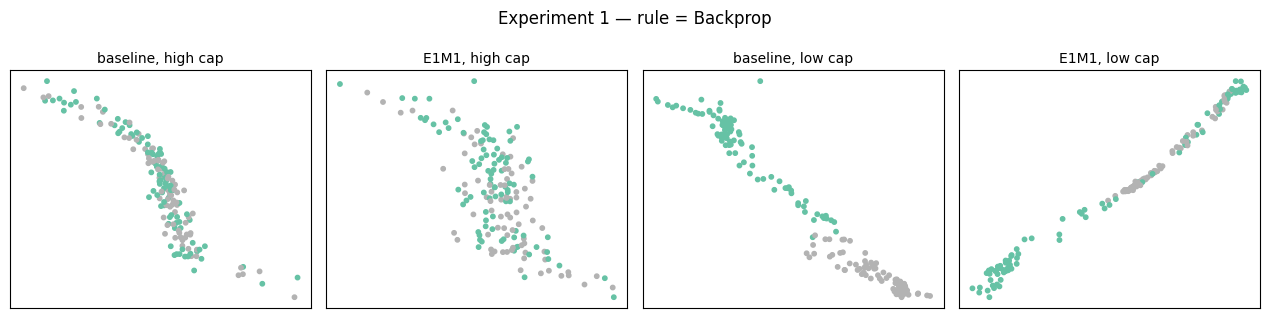

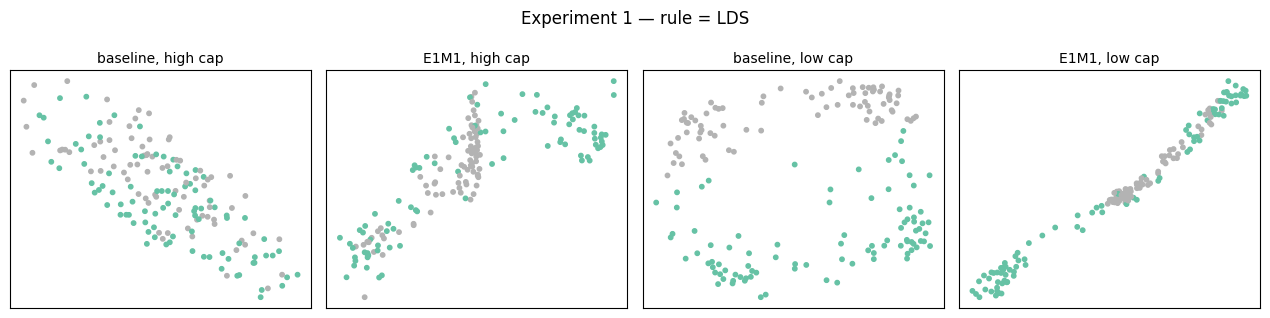

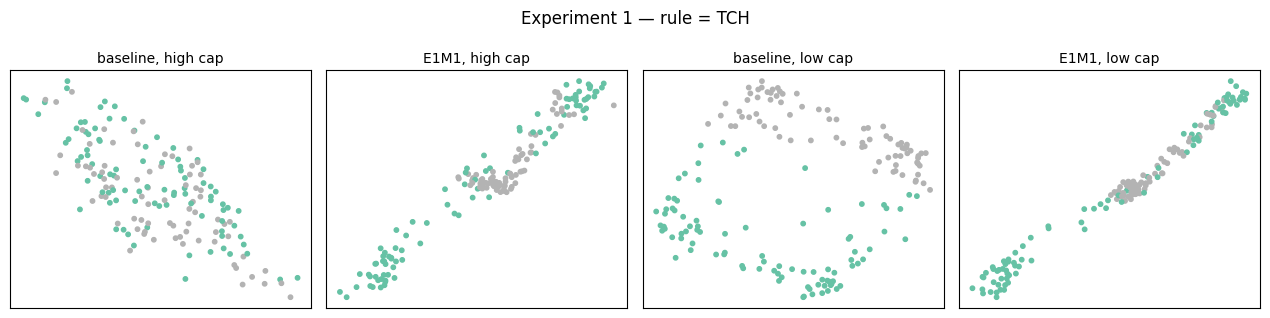

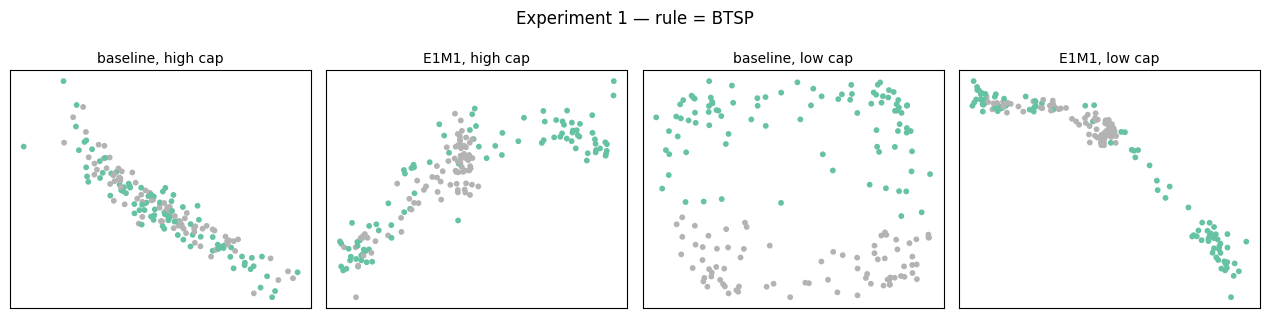

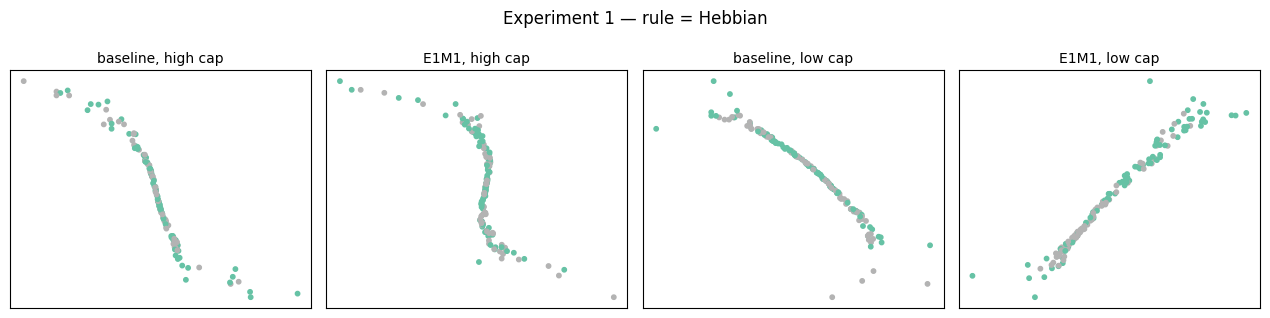

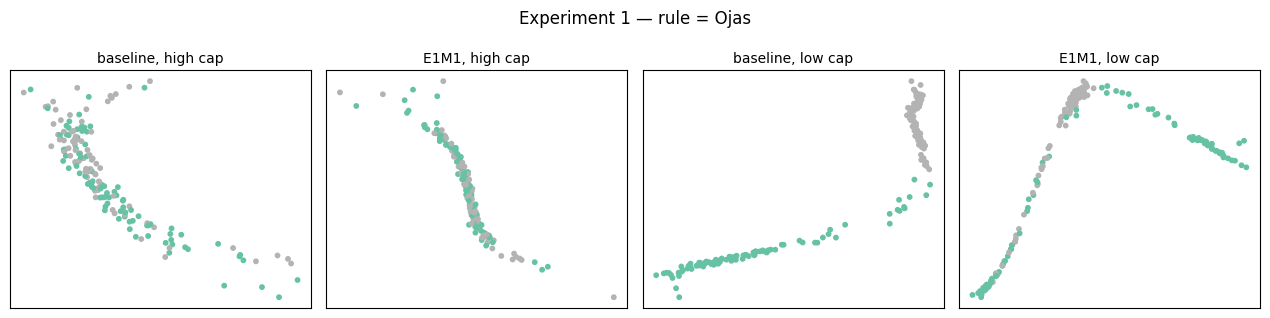

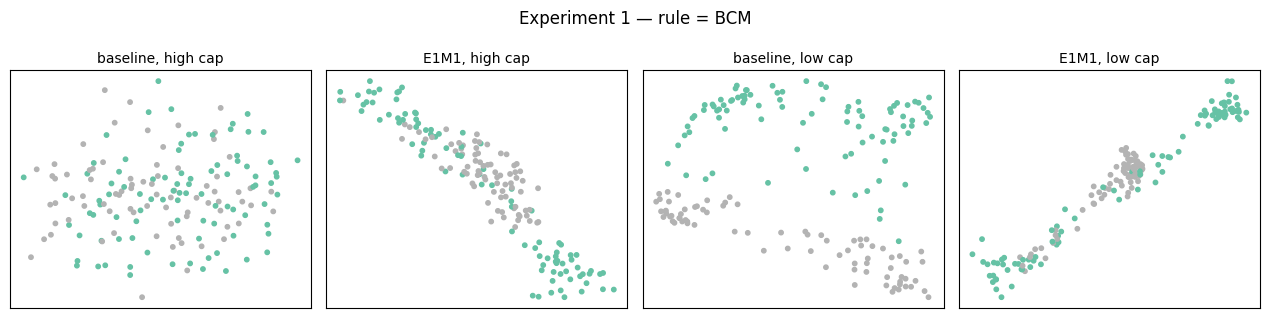

In [ ]:
# Visualize: for each rule, baseline vs E1M1 at low and high capacity
for rule_name in learning_rules:
    entries, titles, colors = [], [], []
    for cap_name in ['high', 'low']:
        for ds_name in ['baseline', 'E1M1']:
            entries.append(exp1_results[rule_name][(cap_name, ds_name)]['mu'])
            titles.append(f"{ds_name}, {cap_name} cap")
            colors.append(freq_class_e1m1)
    plot_latent_grid(entries, titles, colors, suptitle=f"Experiment 1 — rule = {rule_name}")

### Quantifying specialization

For each rule, compare the **E1M1 low-capacity** embedding to the **baseline
low-capacity** embedding (same probe images), aggregated by frequency class.

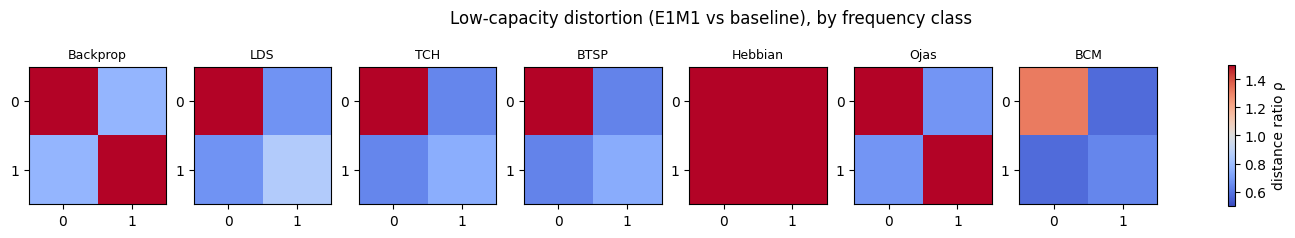

,rule,frequent_class_rho,rare_class_rho,specialization_index
4,Hebbian,12.943925,5.697856,7.246069
5,Ojas,5.622143,2.290149,3.331994
0,Backprop,3.445614,2.190847,1.254767
1,LDS,1.843575,0.856785,0.986791
3,BTSP,1.632513,0.738656,0.893857
2,TCH,1.587687,0.747832,0.839855
6,BCM,1.319121,0.638406,0.680715


In [ ]:
specialization_rows = []
fig, axes = plt.subplots(1, len(learning_rules), figsize=(2.6 * len(learning_rules), 2.6))
for ax, rule_name in zip(axes, learning_rules):
    embA = exp1_results[rule_name][('low', 'baseline')]['mu']
    embB = exp1_results[rule_name][('low', 'E1M1')]['mu']
    M, classes = distortion_matrix(embA, embB, freq_class_e1m1)
    im = ax.imshow(M, cmap='coolwarm', vmin=0.5, vmax=1.5)
    ax.set_xticks(range(len(classes))); ax.set_yticks(range(len(classes)))
    ax.set_title(rule_name, fontsize=9)
    specialization_rows.append({
        'rule': rule_name,
        'frequent_class_rho': M[0, 0],
        'rare_class_rho': M[1, 1],
        'specialization_index': M[0, 0] - M[1, 1],
    })
fig.suptitle("Low-capacity distortion (E1M1 vs baseline), by frequency class")
fig.colorbar(im, ax=axes, shrink=0.7, label='distance ratio ρ')
plt.show()

pd.DataFrame(specialization_rows).sort_values('specialization_index', ascending=False)

## 7. Experiment 2 — capacity × task, across learning rules

Baseline (reconstruction only) vs. E2M1 hybrid (β-VAE + linear classifier on
`x_UC <= x_LC`, jointly trained, classifier curriculum-weighted as in Section 3).

In [ ]:
def task_e2m1(u, l):
    return int(u <= l)

exp2_results = {}
probe_imgs2, probe_uc2, probe_lc2, probe_cls2 = make_probe_set(task=task_e2m1)

t0 = time.time()
for rule_name, rule_cfg in learning_rules.items():
    exp2_results[rule_name] = {}
    for cap_name, cap_val in CAPACITIES.items():
        ds_base = CorridorsDataset(N_TRAIN, bias=None, task=task_e2m1, seed=2)
        model_base, hist_base = train_model(rule_cfg, cap_val, ds_base, n_epochs=N_EPOCHS,
                                             batch_size=BATCH_SIZE, n_classes=None)
        mu_base = embed_probe(model_base, probe_imgs2)

        ds_hyb = CorridorsDataset(N_TRAIN, bias=None, task=task_e2m1, seed=2)
        model_hyb, hist_hyb = train_model(rule_cfg, cap_val, ds_hyb, n_epochs=N_EPOCHS,
                                           batch_size=BATCH_SIZE, n_classes=2)
        mu_hyb = embed_probe(model_hyb, probe_imgs2)

        exp2_results[rule_name][cap_name] = {
            'baseline_mu': mu_base, 'baseline_hist': hist_base,
            'E2M1_mu': mu_hyb, 'E2M1_hist': hist_hyb,
        }
        print(f"[Exp2] {rule_name:8s} cap={cap_name:4s} "
              f"baseline_loss={hist_base[-1]['loss']:8.4f} "
              f"E2M1_loss={hist_hyb[-1]['loss']:8.4f}  ({time.time()-t0:5.1f}s elapsed)")
print("Experiment 2 complete.")

[Exp2] Backprop cap=low  baseline_loss=  0.1472 E2M1_loss=  0.8061  ( 18.3s elapsed)
[Exp2] Backprop cap=high baseline_loss=  0.1844 E2M1_loss=  1.4394  ( 37.4s elapsed)
[Exp2] LDS      cap=low  baseline_loss=  0.1469 E2M1_loss=  0.7901  (105.4s elapsed)
[Exp2] LDS      cap=high baseline_loss=  0.1761 E2M1_loss=  1.2839  (168.7s elapsed)
[Exp2] TCH      cap=low  baseline_loss=  0.1478 E2M1_loss=  0.7960  (202.4s elapsed)
[Exp2] TCH      cap=high baseline_loss=  0.1766 E2M1_loss=  1.4932  (236.1s elapsed)
[Exp2] BTSP     cap=low  baseline_loss=  0.1474 E2M1_loss=  0.7923  (390.7s elapsed)
[Exp2] BTSP     cap=high baseline_loss=  0.1764 E2M1_loss=  1.4931  (549.6s elapsed)
[Exp2] Hebbian  cap=low  baseline_loss=  0.1563 E2M1_loss=  0.8028  (607.9s elapsed)
[Exp2] Hebbian  cap=high baseline_loss=  0.1737 E2M1_loss=  1.4921  (665.2s elapsed)
[Exp2] Ojas     cap=low  baseline_loss=  0.1525 E2M1_loss=  0.8099  (697.6s elapsed)
[Exp2] Ojas     cap=high baseline_loss=  0.1831 E2M1_loss=  1.571

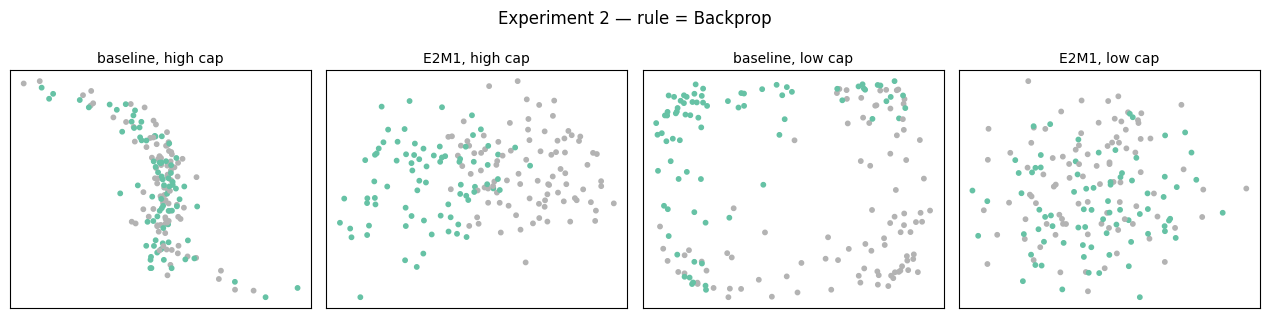

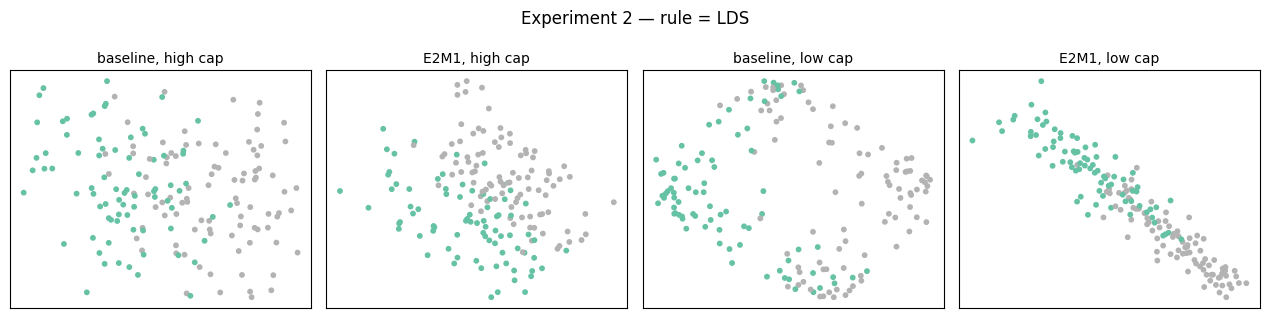

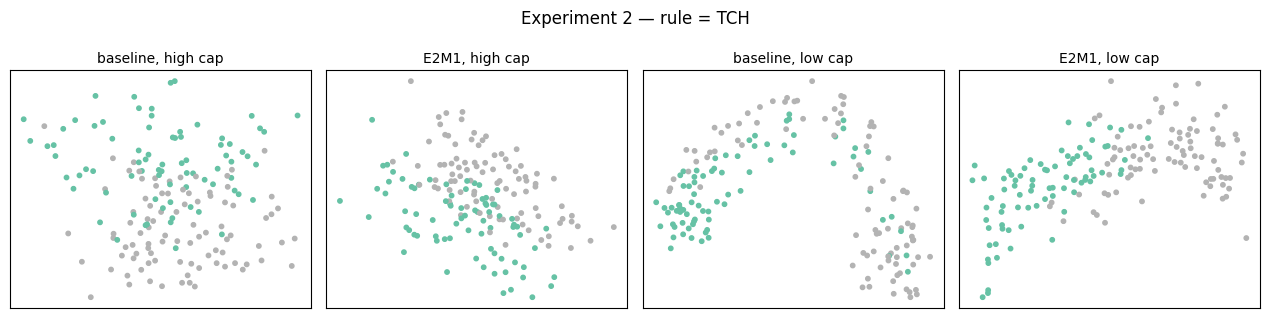

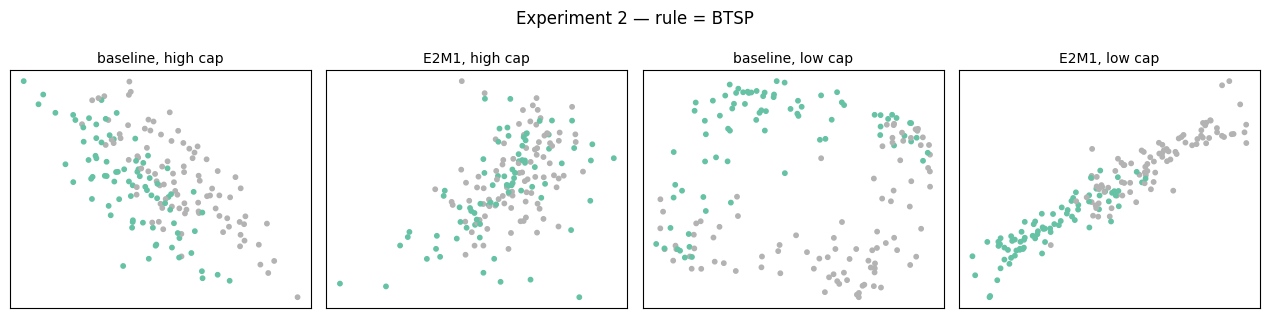

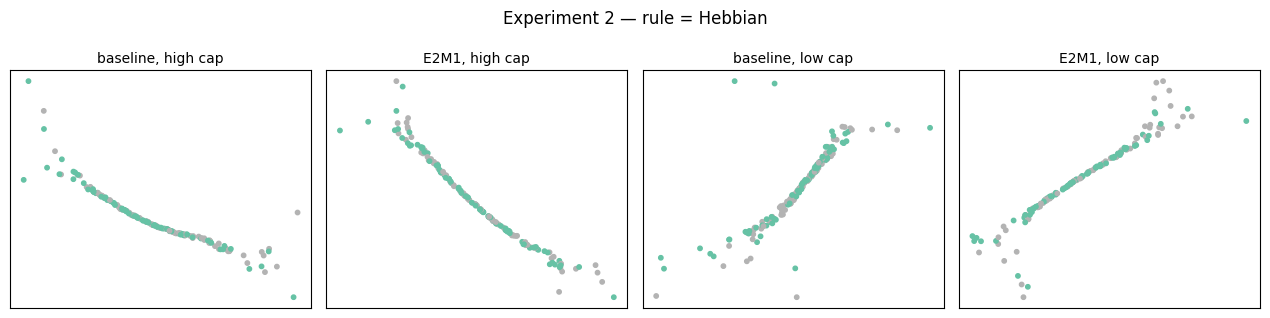

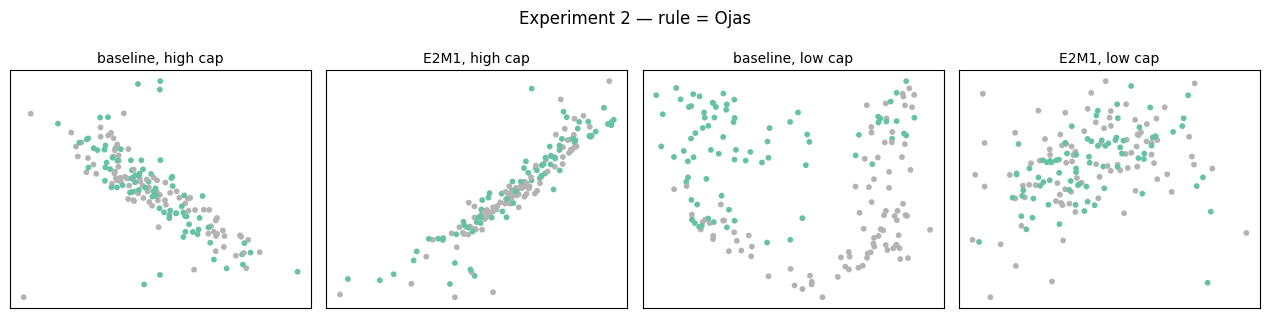

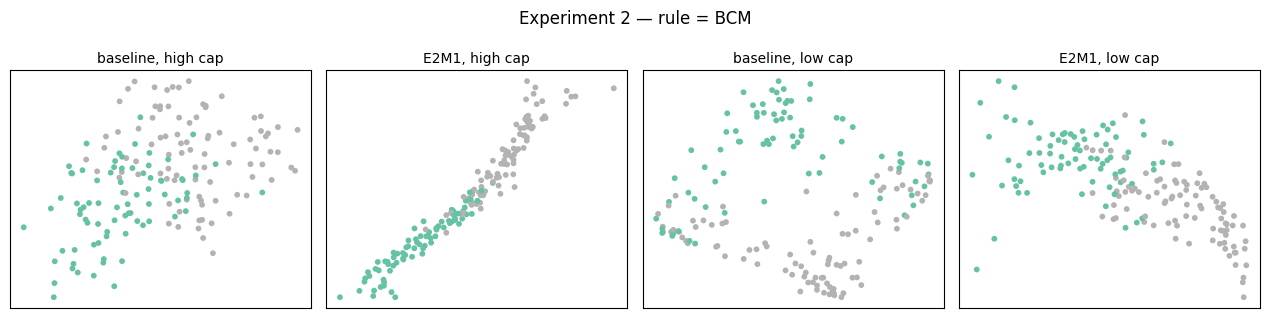

In [ ]:
for rule_name in learning_rules:
    entries, titles, colors = [], [], []
    for cap_name in ['high', 'low']:
        entries.append(exp2_results[rule_name][cap_name]['baseline_mu'])
        titles.append(f"baseline, {cap_name} cap")
        colors.append(probe_cls2)
        entries.append(exp2_results[rule_name][cap_name]['E2M1_mu'])
        titles.append(f"E2M1, {cap_name} cap")
        colors.append(probe_cls2)
    plot_latent_grid(entries, titles, colors, suptitle=f"Experiment 2 — rule = {rule_name}")

### Quantifying orthogonalization

Orthogonalization index = mean between-class distance ratio − mean within-class
distance ratio, comparing **E2M1 vs. baseline** at a given capacity (same probe images).

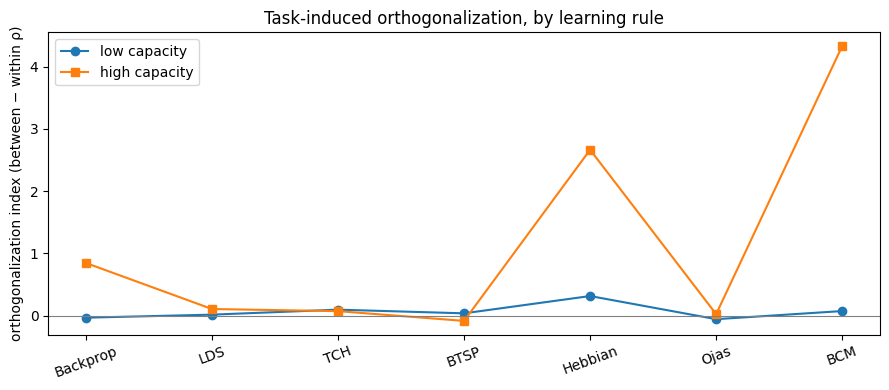

,rule,capacity,within_class_rho,between_class_rho,orthogonalization_index
0,Backprop,low,0.073527,0.038639,-0.034888
1,Backprop,high,1.482105,2.325829,0.843723
2,LDS,low,0.184144,0.197964,0.013820
3,LDS,high,1.046412,1.150807,0.104394
4,TCH,low,0.346847,0.440796,0.093949
5,TCH,high,1.107782,1.177764,0.069982
6,BTSP,low,0.203712,0.238739,0.035027
7,BTSP,high,1.047180,0.960672,-0.086508
8,Hebbian,low,4.069341,4.382201,0.312860
9,Hebbian,high,3.438052,6.101462,2.663410


In [ ]:
ortho_rows = []
for rule_name in learning_rules:
    for cap_name in ['low', 'high']:
        embA = exp2_results[rule_name][cap_name]['baseline_mu']
        embB = exp2_results[rule_name][cap_name]['E2M1_mu']
        M, classes = distortion_matrix(embA, embB, probe_cls2)
        within = np.nanmean([M[i, i] for i in range(len(classes))])
        between = np.nanmean([M[i, j] for i in range(len(classes)) for j in range(len(classes)) if i != j])
        ortho_rows.append({'rule': rule_name, 'capacity': cap_name,
                            'within_class_rho': within, 'between_class_rho': between,
                            'orthogonalization_index': between - within})
ortho_df = pd.DataFrame(ortho_rows)

fig, ax = plt.subplots(figsize=(9, 4))
for cap_name, marker in [('low', 'o'), ('high', 's')]:
    sub = ortho_df[ortho_df.capacity == cap_name]
    ax.plot(sub['rule'], sub['orthogonalization_index'], marker=marker, label=f'{cap_name} capacity')
ax.axhline(0, color='gray', lw=0.8)
ax.set_ylabel('orthogonalization index (between − within ρ)')
ax.set_title('Task-induced orthogonalization, by learning rule')
ax.legend(); plt.xticks(rotation=20); plt.tight_layout(); plt.show()
ortho_df

## 8. Summary across all three distortion signatures

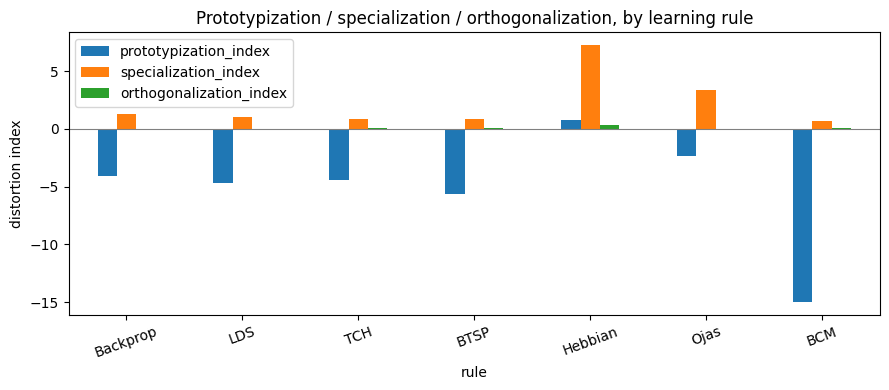

,prototypization_index,specialization_index,orthogonalization_index
rule,,,
Backprop,-4.058309,1.254767,-0.034888
LDS,-4.727032,0.986791,0.013820
TCH,-4.409855,0.839855,0.093949
BTSP,-5.617007,0.893857,0.035027
Hebbian,0.770616,7.246069,0.312860
Ojas,-2.338640,3.331994,-0.058863
BCM,-15.014397,0.680715,0.071574


In [ ]:
proto_rows = []
for rule_name in learning_rules:
    emb_high = exp1_results[rule_name][('high', 'baseline')]['mu']
    emb_low = exp1_results[rule_name][('low', 'baseline')]['mu']
    dA = squareform(pdist(emb_high))
    dB = squareform(pdist(emb_low))
    off = ~np.eye(len(dA), dtype=bool)
    rho = dB[off] / np.maximum(dA[off], 1e-8)
    proto_rows.append({'rule': rule_name, 'prototypization_index': 1 - np.median(rho)})
proto_df = pd.DataFrame(proto_rows)

summary = (proto_df
           .merge(pd.DataFrame(specialization_rows)[['rule', 'specialization_index']], on='rule')
           .merge(ortho_df[ortho_df.capacity == 'low'][['rule', 'orthogonalization_index']], on='rule'))
summary = summary.set_index('rule')

fig, ax = plt.subplots(figsize=(9, 4))
summary.plot(kind='bar', ax=ax)
ax.axhline(0, color='gray', lw=0.8)
ax.set_ylabel('distortion index')
ax.set_title('Prototypization / specialization / orthogonalization, by learning rule')
plt.xticks(rotation=20); plt.tight_layout(); plt.show()
summary

## 9. Remaining known simplifications (still disclosed, unchanged from v1)

- Encoder/decoder is a small dense MLP, not the real conv stack in
  `src/models/beta_vae.py` (13×13 is small enough that this shouldn't change the
  qualitative capacity/distortion story, but absolute numbers won't match).
- `delta = -d(loss)/d(mu)` from single-pass autograd stands in for EIANN's literal
  two-phase recurrent dendritic-target-propagation signal (`plateau`, computed via
  `backward_update_layer_dendritic_state` / `backward_update_layer_activity` over
  several equilibration steps in `EIANN/rules/*.py`). This notebook's architecture is
  feedforward, so there's no recurrent circuit to equilibrate — Eq. 27 of Galloni et al.
  shows this is the correct leading-order reduction for `Hebbian_Temporal_Contrast`
  specifically, and a structurally analogous approximation for `BP_like_2E`/`BTSP_19`.
- The surrounding encoder backbone / decoder / logvar head still train with ordinary
  batched Adam (not batch_size=1) for tractable Colab runtime — only the designated
  plastic layer (`mu_head`) now updates sample-by-sample, matching EIANN's per-rule
  update semantics exactly, even though the rest of the network doesn't share its
  literal batch_size=1 training regime.
- `max_pop_fraction`/`stochastic` unit-selection (real EIANN sparsifies which units get
  plastic updates each step) is implemented and available as a kwarg on `LDS`/`BTSP`,
  but isn't exercised by the exact `learning_rules` dict you specified (defaults to
  `max_pop_fraction=1.0`, i.e., all units), so it doesn't change these particular results
  — pass it explicitly if you want to explore that dimension.